<a href="https://colab.research.google.com/github/AmitSP-beep/Classification-Model/blob/main/Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing Basic Libraries**

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Importing Dataset**

In [25]:
df=pd.read_csv('/content/drive/MyDrive/datasets/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df['Department'].value_counts()

,count
Department,
Research & Development,961
Sales,446
Human Resources,63


**General Idea about Data**

In [26]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


**Checking data type for columns in dataset**

In [27]:
df.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


**Some variables in the dataset may lack relevance to the target variable, providing little to no insightful information. Identifying and excluding these variables can enhance the overall analysis by focusing on those that meaningfully contribute to understanding the factors influencing the target outcome.**

In [28]:
df1=df.drop(['EmployeeCount','EmployeeNumber','Over18','StandardHours'],axis=1)
df1.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

**The remaining columns in the dataset provide valuable information related to the target variable. However, we should be cautious of potential multicollinearity among these variables, which could impact the analysis. We will address this issue in the later stages of our analysis to ensure robust model performance and interpretation.**

**Checking for NA values**


In [29]:
df1.isna().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0


**As there is no NA in Data lets start encoding the data using OneHotEncoding**

In [30]:
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer
tf1=ColumnTransformer(transformers=[
    ('ohe',OneHotEncoder(sparse_output=False,drop='first'),['BusinessTravel','Department','EducationField','Gender','JobRole','MaritalStatus','OverTime'])


                                    ],remainder='drop'
       )
encoded=tf1.fit_transform(df1)
df2=pd.DataFrame(encoded,columns=tf1.get_feature_names_out())
df2

,ohe__BusinessTravel_Travel_Frequently,ohe__BusinessTravel_Travel_Rarely,ohe__Department_Research & Development,ohe__Department_Sales,ohe__EducationField_Life Sciences,ohe__EducationField_Marketing,ohe__EducationField_Medical,ohe__EducationField_Other,ohe__EducationField_Technical Degree,ohe__Gender_Male,...,ohe__JobRole_Laboratory Technician,ohe__JobRole_Manager,ohe__JobRole_Manufacturing Director,ohe__JobRole_Research Director,ohe__JobRole_Research Scientist,ohe__JobRole_Sales Executive,ohe__JobRole_Sales Representative,ohe__MaritalStatus_Married,ohe__MaritalStatus_Single,ohe__OverTime_Yes
0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
4,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1466,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1467,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1468,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [31]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df2['Attrition']=le.fit_transform(df1['Attrition'])
df2

,ohe__BusinessTravel_Travel_Frequently,ohe__BusinessTravel_Travel_Rarely,ohe__Department_Research & Development,ohe__Department_Sales,ohe__EducationField_Life Sciences,ohe__EducationField_Marketing,ohe__EducationField_Medical,ohe__EducationField_Other,ohe__EducationField_Technical Degree,ohe__Gender_Male,...,ohe__JobRole_Manager,ohe__JobRole_Manufacturing Director,ohe__JobRole_Research Director,ohe__JobRole_Research Scientist,ohe__JobRole_Sales Executive,ohe__JobRole_Sales Representative,ohe__MaritalStatus_Married,ohe__MaritalStatus_Single,ohe__OverTime_Yes,Attrition
0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0
2,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1
3,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0
4,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
1466,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
1467,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0
1468,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0


**Let's join the two dataframes encoded and rest numerical columns**

In [32]:
df_n=df1.drop(['Attrition','BusinessTravel','Department','EducationField','Gender','JobRole','MaritalStatus','OverTime'],axis=1)
df_n
new_df=pd.concat([df_n,df2],axis=1)
new_df


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,ohe__JobRole_Manager,ohe__JobRole_Manufacturing Director,ohe__JobRole_Research Director,ohe__JobRole_Research Scientist,ohe__JobRole_Sales Executive,ohe__JobRole_Sales Representative,ohe__MaritalStatus_Married,ohe__MaritalStatus_Single,ohe__OverTime_Yes,Attrition
0,41,1102,1,2,2,94,3,2,4,5993,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1
1,49,279,8,1,3,61,2,2,2,5130,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0
2,37,1373,2,2,4,92,2,1,3,2090,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1
3,33,1392,3,4,4,56,3,1,3,2909,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0
4,27,591,2,1,1,40,3,1,2,3468,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,3,41,4,2,4,2571,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
1466,39,613,6,1,4,42,2,3,1,9991,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
1467,27,155,4,3,2,87,4,2,2,6142,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0
1468,49,1023,2,3,4,63,2,2,2,5390,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0


In [33]:
new_df.columns

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'ohe__BusinessTravel_Travel_Frequently',
       'ohe__BusinessTravel_Travel_Rarely',
       'ohe__Department_Research & Development', 'ohe__Department_Sales',
       'ohe__EducationField_Life Sciences', 'ohe__EducationField_Marketing',
       'ohe__EducationField_Medical', 'ohe__EducationField_Other',
       'ohe__EducationField_Technical Degree', 'ohe__Gender_Male',
       'ohe__JobRole_Human Resources', 'ohe__JobRole_Laboratory Technician',
       'ohe__JobRole_Manager', 'ohe__JobRole_Manufactu

**Now let's start outlier detection**

- **Age**

<function matplotlib.pyplot.show(close=None, block=None)>

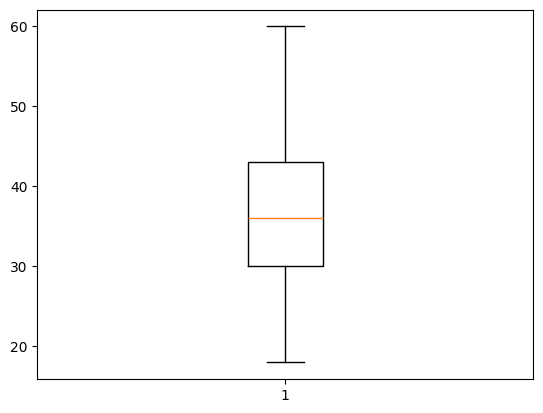

In [34]:
plt.boxplot(new_df['Age'])
plt.show

- **DailyRate**

<function matplotlib.pyplot.show(close=None, block=None)>

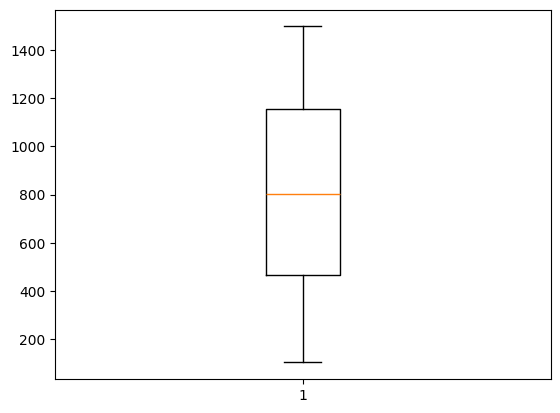

In [35]:
plt.boxplot(new_df['DailyRate'])
plt.show

- **DistanceFromHome**

<function matplotlib.pyplot.show(close=None, block=None)>

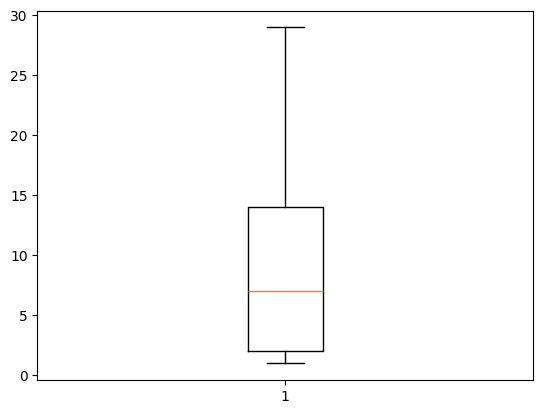

In [36]:
plt.boxplot(new_df['DistanceFromHome'])
plt.show

- **HourlyRate**

<function matplotlib.pyplot.show(close=None, block=None)>

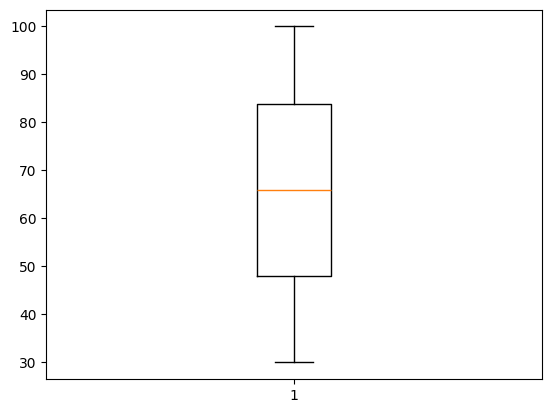

In [37]:
plt.boxplot(new_df['HourlyRate'])
plt.show

- **MonthlyIncome**

<function matplotlib.pyplot.show(close=None, block=None)>

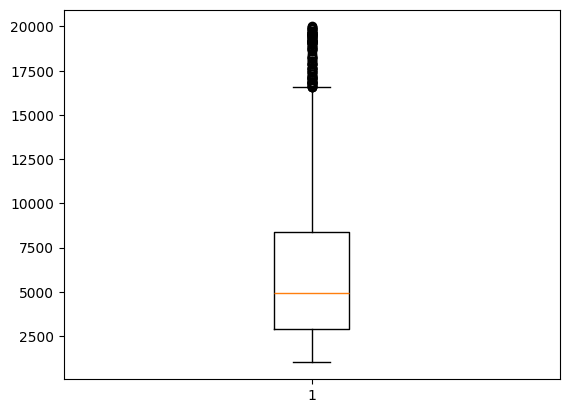

In [38]:
plt.boxplot(new_df['MonthlyIncome'])
plt.show

**Analysing Outliers for above plot**

<function matplotlib.pyplot.show(close=None, block=None)>

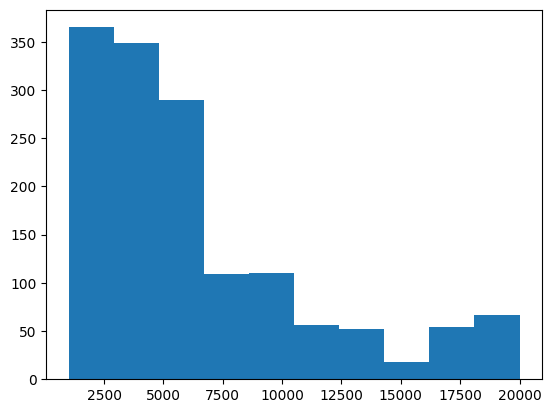

In [39]:
plt.hist(new_df['MonthlyIncome'])
plt.show

**Even though they are outliers but they  are genuine data points, we’ll retain them during the Exploratory Data Analysis (EDA) to preserve the integrity of the dataset. However, during regression modeling, we can apply transformations (like log or square root) to mitigate their influence on the coefficients. This approach allows us to balance the inclusion of real data while minimizing the potential distortion caused by extreme values on the model's performance and interpretation.**

- **MonthalyRate**

<function matplotlib.pyplot.show(close=None, block=None)>

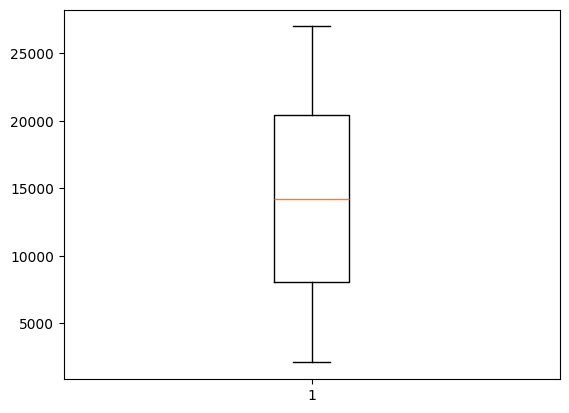

In [40]:
plt.boxplot(new_df['MonthlyRate'])
plt.show

- **PercentageHike**

<function matplotlib.pyplot.show(close=None, block=None)>

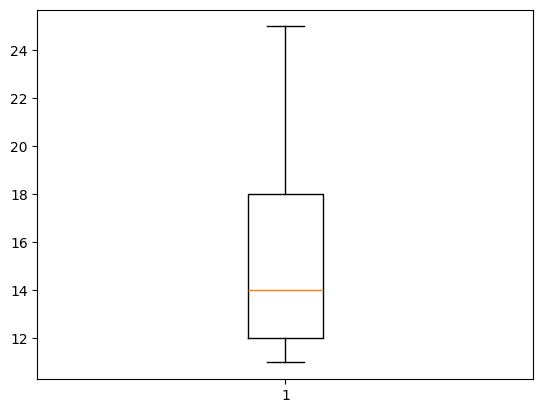

In [41]:
plt.boxplot(new_df['PercentSalaryHike'])
plt.show

- **YearsAtCompany**

<function matplotlib.pyplot.show(close=None, block=None)>

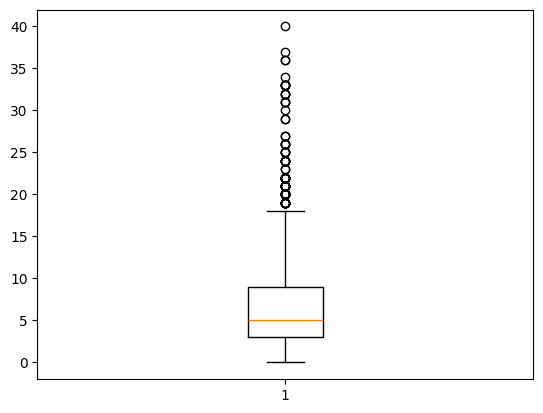

In [42]:
plt.boxplot(new_df['YearsAtCompany'])
plt.show

**We can comment same to the outliers of these column as of MonthlyIncome**

- **TotalWorkingHours**

<function matplotlib.pyplot.show(close=None, block=None)>

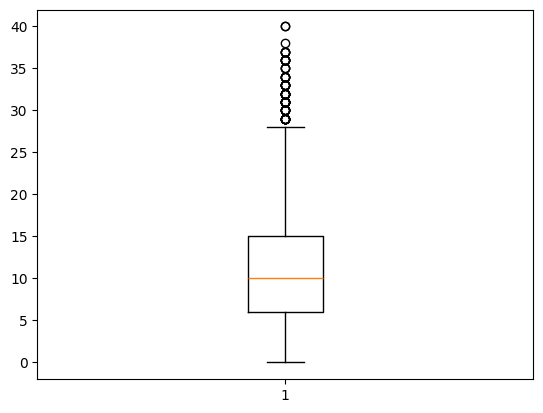

In [43]:
plt.boxplot(new_df['TotalWorkingYears'])
plt.show

**These outliers are also genuine data points so we'll control them while model fitting but let's keep them in EDA**

- **YearsWithCurrentManager**

<function matplotlib.pyplot.show(close=None, block=None)>

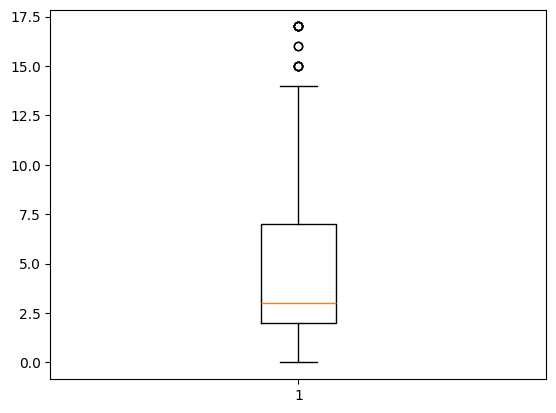

In [44]:
plt.boxplot(new_df['YearsWithCurrManager'])
plt.show

**Based on the boxplots, it is evident that there are no significant outliers in our data. Therefore, we can confidently proceed with the Exploratory Data Analysis (EDA).**

**Now let's plot pairplot for getting general idea about numeric columns of our data**

In [45]:
nwedf=new_df.to_csv('/content/drive/MyDrive/datasets/EAD.csv')

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

#sns.pairplot(new_df[['Age', 'Attrition', 'DistanceFromHome', 'MonthlyIncome',
                 #'JobSatisfaction', 'TotalWorkingYears', 'YearsAtCompany',
                 #'YearsSinceLastPromotion', 'WorkLifeBalance']],
#             )

#plt.show()


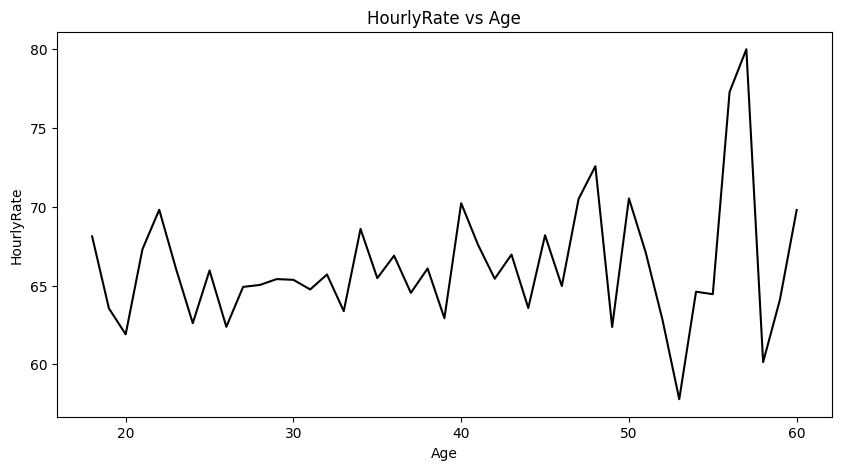

In [47]:
gr_age=new_df.groupby('Age')['HourlyRate'].mean().reset_index()
gr_age
plt.figure(figsize=(10,5))
sns.lineplot(x='Age',y='HourlyRate',color='black',data=gr_age)
plt.xlabel('Age')
plt.ylabel('HourlyRate')
plt.title('HourlyRate vs Age')

plt.show()


**There's a fair amount of fluctuation in hourly rates across ages, with no clear trend such as a consistent increase or decrease. This suggests that hourly rates are fairly variable regardless of age.**

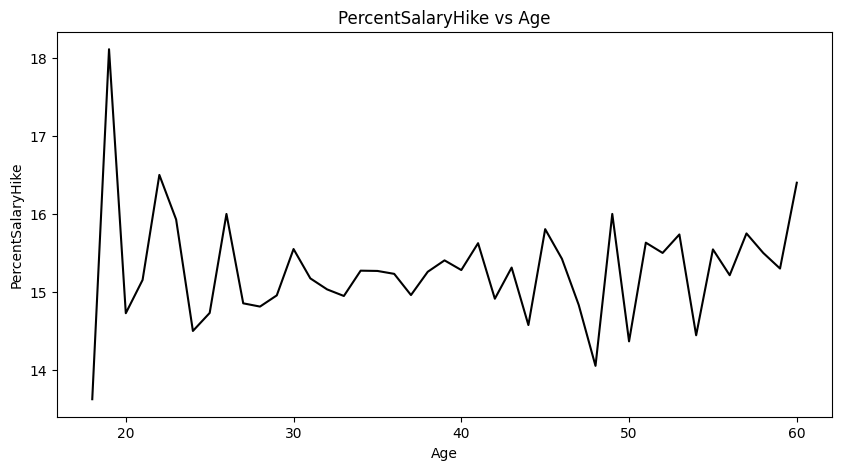

In [48]:
gr_age2=new_df.groupby('Age')['PercentSalaryHike'].mean().reset_index()
gr_age
plt.figure(figsize=(10,5))
sns.lineplot(x='Age',y='PercentSalaryHike',color='black',data=gr_age2)
plt.xlabel('Age')
plt.ylabel('PercentSalaryHike')
plt.title('PercentSalaryHike vs Age')

plt.show()


**There is an initial increase in the percentage of salary hikes associated with age, followed by a subsequent decline. This trend may be driven by a desire to attract and retain talent in the early stages of a career, suggesting that younger employees receive more significant raises to incentivize their engagement and loyalty.**

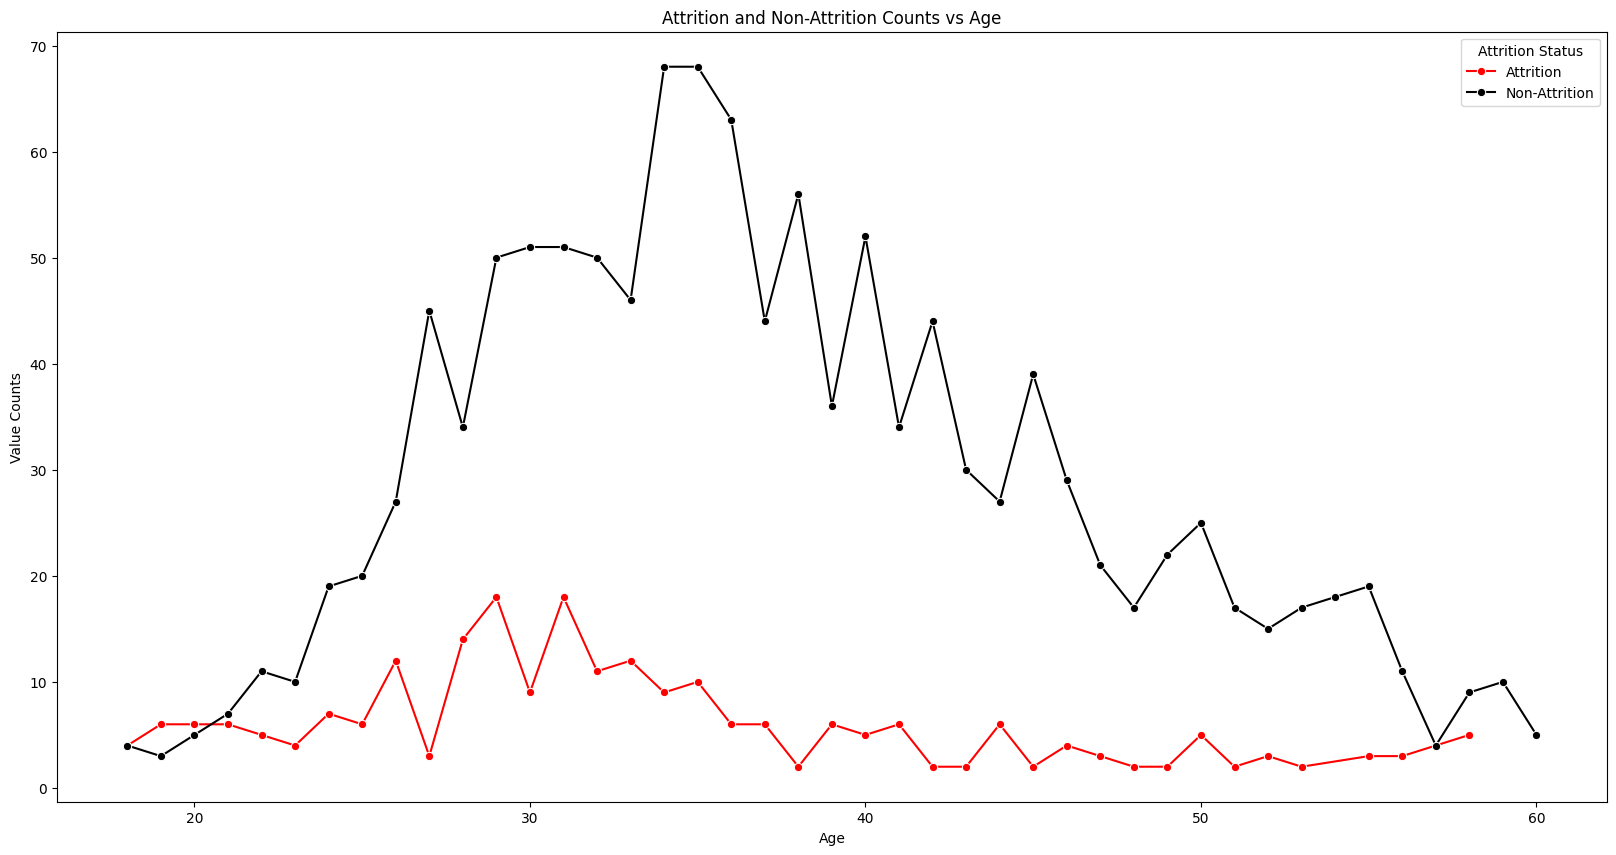

In [49]:
gr_age3 = new_df.groupby(['Age', 'Attrition']).size().reset_index(name='Count')

dff1 = gr_age3[gr_age3['Attrition'] == 1]
dff2 = gr_age3[gr_age3['Attrition'] == 0]

plt.figure(figsize=(20, 10))

sns.lineplot(data=dff1, x='Age', y='Count', label='Attrition', color='Red', marker='o')

sns.lineplot(data=dff2, x='Age', y='Count', label='Non-Attrition', color='Black', marker='o')
plt.xlabel('Age')
plt.ylabel('Value Counts')
plt.title('Attrition and Non-Attrition Counts vs Age')
plt.legend(title='Attrition Status')
plt.show()

- **Young employees (20-30)**:

 Attrition rates are relatively low, but gradually increase up to the early 30s. Non-attrition counts also rise, indicating that younger employees are more likely to stay, though some attrition occurs as career paths become more defined.

- **Mid-career employees (30-40)**:

 Non-attrition peaks around age 35, suggesting that individuals in this age group, likely experiencing more stability in their personal lives (e.g., marriage, family), are less likely to leave. Attrition is relatively stable but lower than non-attrition.

- **Older employees (40+)**:

 Both attrition and non-attrition steadily decrease with age, though attrition remains consistently lower across all age groups. This could imply that older employees either stay due to job security or exit the workforce for retirement or other reasons.

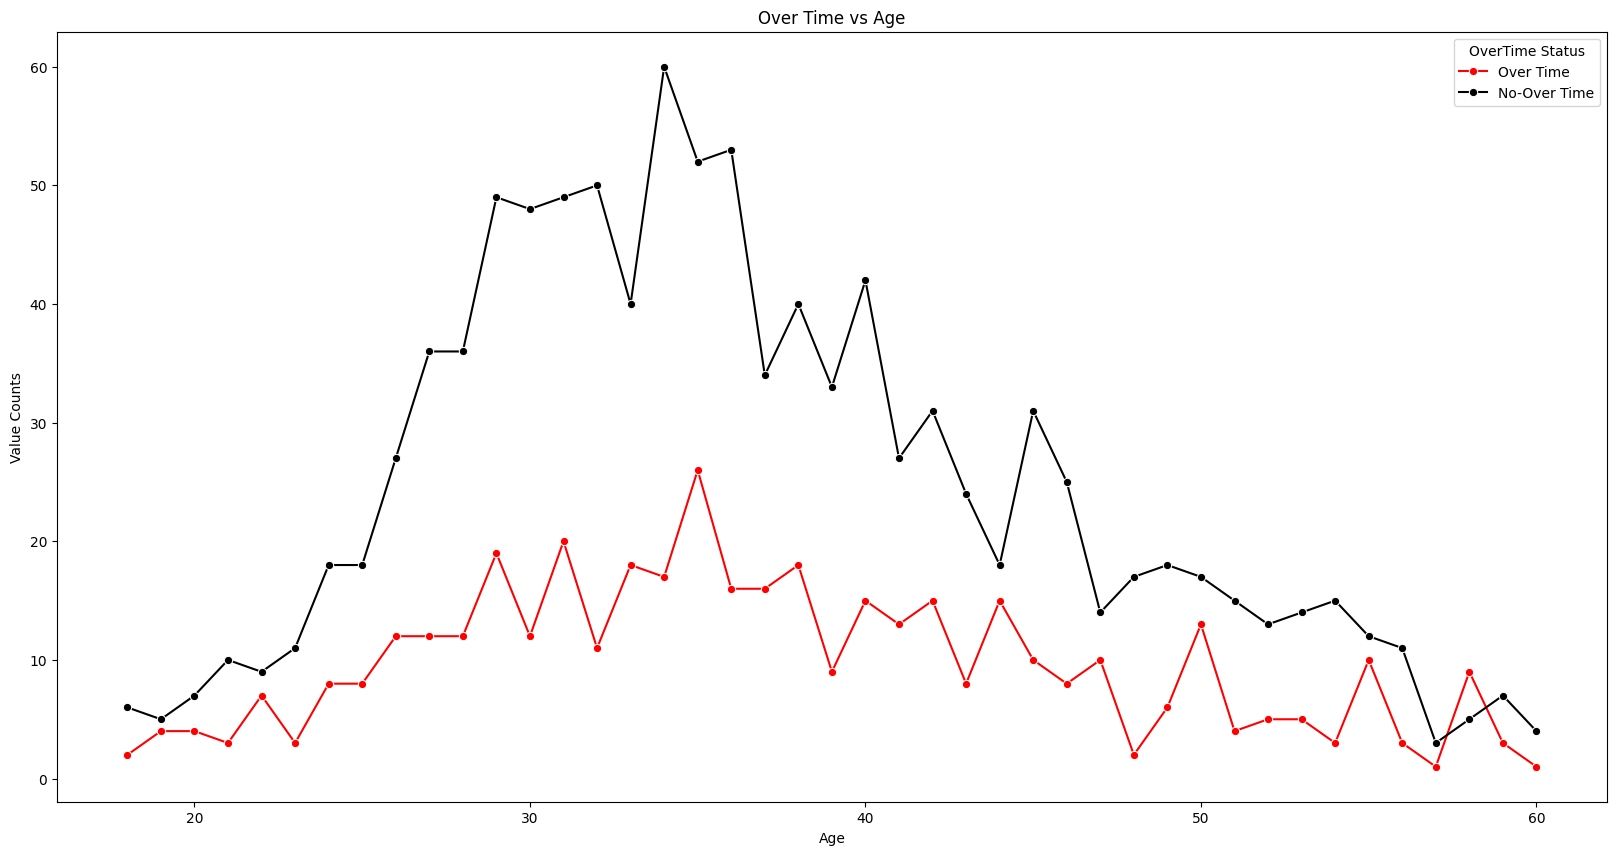

In [50]:
gr_age4 = new_df.groupby(['Age', 'ohe__OverTime_Yes']).size().reset_index(name='Count')

dff3 = gr_age4[gr_age4['ohe__OverTime_Yes'] == 1]
dff4 = gr_age4[gr_age4['ohe__OverTime_Yes'] == 0]

plt.figure(figsize=(20, 10))

sns.lineplot(data=dff3, x='Age', y='Count', label='Over Time', color='Red', marker='o')

sns.lineplot(data=dff4, x='Age', y='Count', label='No-Over Time', color='Black', marker='o')
plt.xlabel('Age')
plt.ylabel('Value Counts')
plt.title('Over Time vs Age')
plt.legend(title='OverTime Status')
plt.show()

- **Young employees (20-30)**:

 Overtime and no-overtime counts both rise, with a higher number of employees not doing overtime. However, there is still a noticeable proportion of younger employees engaging in overtime.

- **Mid-career employees (30-40)**:

 No-overtime counts peak around age 35, suggesting that many employees in this age group, likely due to personal responsibilities or increased stability, do not engage in overtime. The overtime counts are also relatively high in this age range, showing a balanced split between those opting for overtime and those who do not.

- **Older employees (40+)**:

  Both overtime and no-overtime counts gradually decrease after age 40, but no-overtime remains consistently higher. This indicates that as employees age, they are less likely to work overtime, possibly due to nearing retirement or reduced need for extra work hours.

<Axes: xlabel='RelationshipSatisfaction', ylabel='count'>

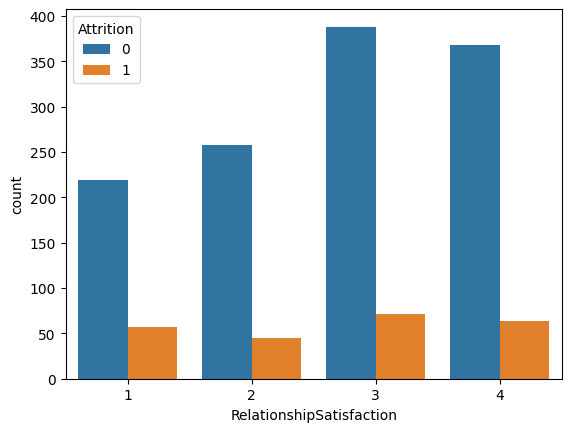

In [51]:
sns.countplot(x='RelationshipSatisfaction', hue='Attrition',data=new_df)

**No significant Relation over these attributes**

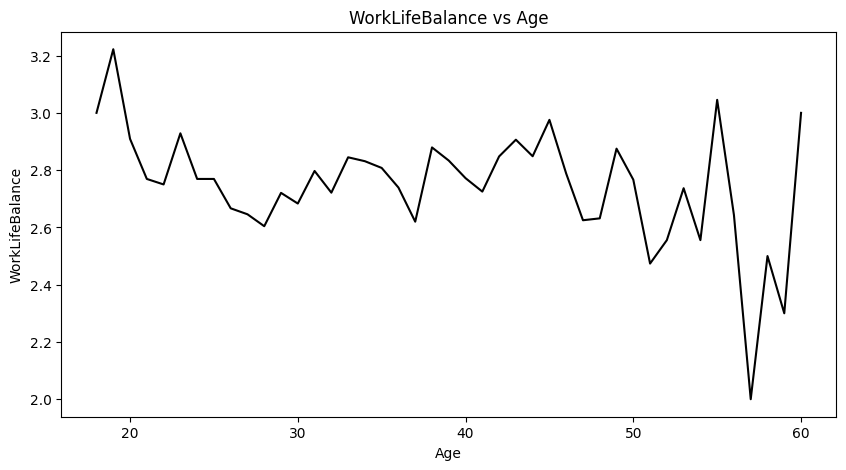

In [52]:
gr_age4=new_df.groupby('Age')['WorkLifeBalance'].mean().reset_index()
gr_age4
plt.figure(figsize=(10,5))
sns.lineplot(x='Age',y='WorkLifeBalance',color='black',data=gr_age4)
plt.xlabel('Age')
plt.ylabel('WorkLifeBalance')
plt.title('WorkLifeBalance vs Age')

plt.show()


- **WorkLifeBalance tends to decline as employees age, particularly from the early 20s to mid-40s. This suggests that younger employees have better work-life balance, while middle-aged employees may struggle more in this section, this may due to addition of responsibilities along with age**

- **Older employees (50+) display mixed trends, but there's a notable improvement in work-life balance around age 60, possibly indicating a shift in job responsibilities, lifestyle changes, or preparation for retirement.**

<Axes: xlabel='PerformanceRating', ylabel='count'>

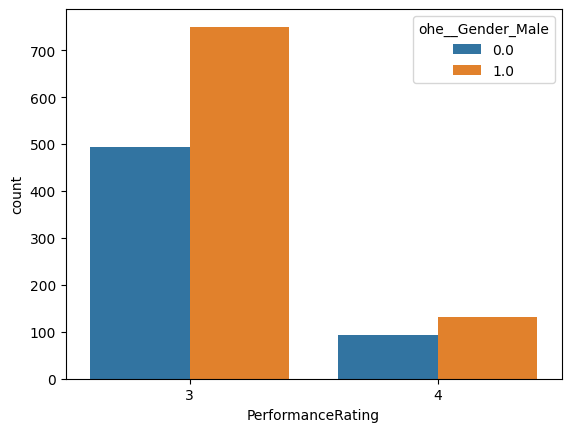

In [53]:
sns.countplot(x='PerformanceRating', hue='ohe__Gender_Male',data=new_df)

- **From the above plot we can say that Males have better performence ratings than females**

<Axes: xlabel='JobSatisfaction', ylabel='count'>

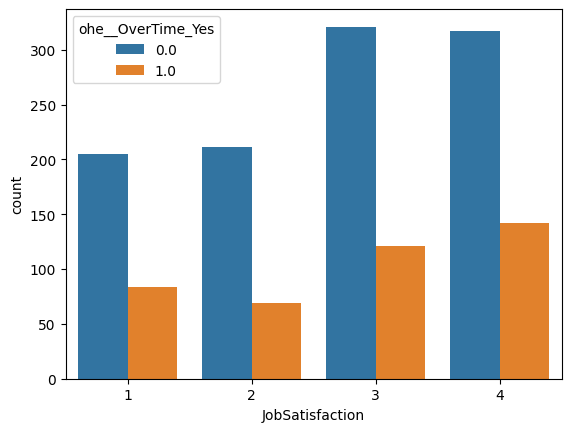

In [54]:
sns.countplot(x='JobSatisfaction', hue='ohe__OverTime_Yes',data=new_df)

**It was expected that as Job Satisfaction increases (moving from rating 1 to 4), the number of employees doing overtime would decrease. This would suggest that more satisfied employees might not feel the need to work beyond their regular hours. However, surprisingly, the opposite trend appears in the data—there is an increase in the number of employees working overtime, particularly among those with a Job Satisfaction rating of 4.**

<Axes: xlabel='Department', ylabel='count'>

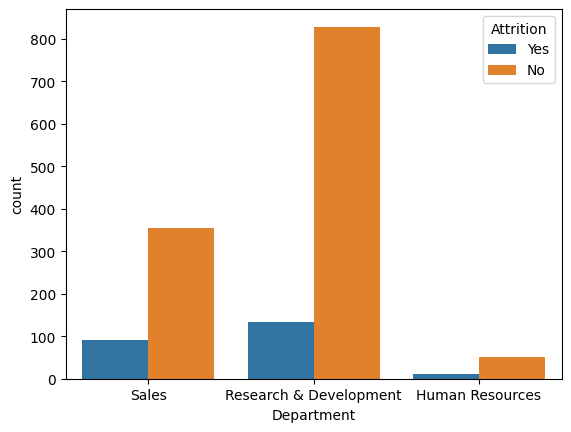

In [55]:
sns.countplot(x='Department', hue='Attrition',data=df)

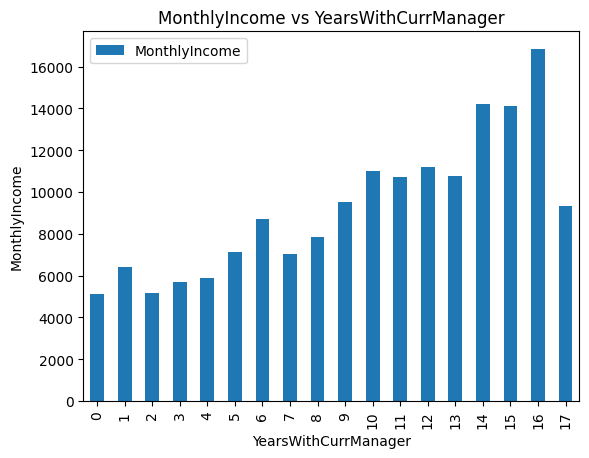

In [56]:
new_df.groupby('YearsWithCurrManager')['MonthlyIncome'].mean().reset_index().plot(x='YearsWithCurrManager',y='MonthlyIncome',kind='bar')
plt.ylabel('MonthlyIncome')
plt.xlabel('YearsWithCurrManager')
plt.title('MonthlyIncome vs YearsWithCurrManager')
plt.show()

**As the number of years with the current manager increases, the average monthly income also rises. This suggests that employees who stay longer under the same manager may experience higher income growth over time.**

**Lets check multicollinearity and proceed with model building**
**We'll define a function for computing VIF**

In [57]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
X_with_const = add_constant(new_df)
vif_with_const = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]
vif_data = pd.DataFrame({
    "Feature": X_with_const.columns,  # Column names including 'const'
    "VIF": vif_with_const
})
vif_data

,Feature,VIF
0,const,448.173324
1,Age,2.093383
2,DailyRate,1.036063
3,DistanceFromHome,1.031315
4,Education,1.083597
5,EnvironmentSatisfaction,1.049590
6,HourlyRate,1.026897
7,JobInvolvement,1.049471
8,JobLevel,14.140403
9,JobSatisfaction,1.041674


In [58]:
f_df=new_df.drop(['JobLevel','MonthlyIncome','ohe__Department_Research & Development','ohe__Department_Sales','ohe__EducationField_Life Sciences','ohe__EducationField_Marketing','ohe__EducationField_Medical','ohe__EducationField_Other','ohe__EducationField_Technical Degree','ohe__JobRole_Human Resources','ohe__JobRole_Laboratory Technician','ohe__JobRole_Manager','ohe__JobRole_Manufacturing Director','ohe__JobRole_Research Director','ohe__JobRole_Research Scientist','ohe__JobRole_Sales Executive','ohe__JobRole_Sales Representative'],axis=1)
f_df

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobSatisfaction,MonthlyRate,NumCompaniesWorked,...,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,ohe__BusinessTravel_Travel_Frequently,ohe__BusinessTravel_Travel_Rarely,ohe__Gender_Male,ohe__MaritalStatus_Married,ohe__MaritalStatus_Single,ohe__OverTime_Yes,Attrition
0,41,1102,1,2,2,94,3,4,19479,8,...,4,0,5,0.0,1.0,0.0,0.0,1.0,1.0,1
1,49,279,8,1,3,61,2,2,24907,1,...,7,1,7,1.0,0.0,1.0,1.0,0.0,0.0,0
2,37,1373,2,2,4,92,2,3,2396,6,...,0,0,0,0.0,1.0,1.0,0.0,1.0,1.0,1
3,33,1392,3,4,4,56,3,3,23159,1,...,7,3,0,1.0,0.0,0.0,1.0,0.0,1.0,0
4,27,591,2,1,1,40,3,2,16632,9,...,2,2,2,0.0,1.0,1.0,1.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,3,41,4,4,12290,4,...,2,0,3,1.0,0.0,1.0,1.0,0.0,0.0,0
1466,39,613,6,1,4,42,2,1,21457,4,...,7,1,7,0.0,1.0,1.0,1.0,0.0,0.0,0
1467,27,155,4,3,2,87,4,2,5174,1,...,2,0,3,0.0,1.0,1.0,1.0,0.0,1.0,0
1468,49,1023,2,3,4,63,2,2,13243,2,...,6,0,8,1.0,0.0,1.0,1.0,0.0,0.0,0


In [59]:
X_with_const_n = add_constant(f_df)
vif_with_const_n = [variance_inflation_factor(X_with_const_n.values, i) for i in range(X_with_const_n.shape[1])]
vif_data_n = pd.DataFrame({
    "Feature": X_with_const_n.columns,  # Column names including 'const'
    "VIF": vif_with_const_n
})
vif_data_n

,Feature,VIF
0,const,224.863298
1,Age,2.066723
2,DailyRate,1.023970
3,DistanceFromHome,1.020167
4,Education,1.061992
5,EnvironmentSatisfaction,1.034347
6,HourlyRate,1.017813
7,JobInvolvement,1.039000
8,JobSatisfaction,1.037313
9,MonthlyRate,1.014383


In [60]:
Y=f_df['Attrition']
X=f_df.drop('Attrition',axis=1)
X.shape


(1470, 27)

**Lets fit the regression model**

In [61]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)


In [62]:
from sklearn.linear_model import LogisticRegression
model1=LogisticRegression()
model1.fit(X_train,Y_train)

LogisticRegression()

In [63]:
from sklearn.metrics import accuracy_score
Y_pred=model1.predict(X_test)
accuracy_score(Y_test,Y_pred)

0.8843537414965986

PCA

In [64]:
from sklearn.decomposition import PCA
pca=PCA(n_components=None)
X_train1=pca.fit_transform(X_train)
X_test1=pca.transform(X_test)

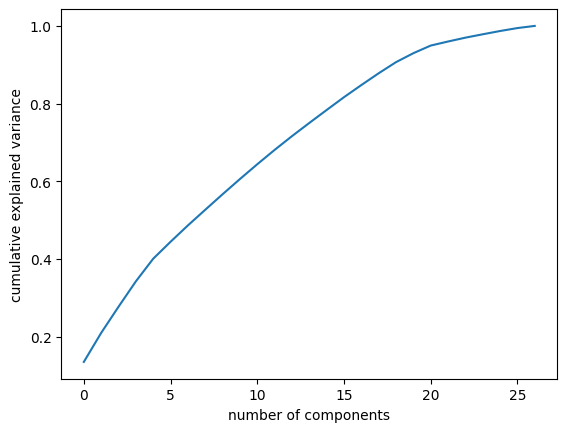

In [65]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.show()

In [66]:
pca=PCA(n_components=19)
X_train_trf=pca.fit_transform(X_train)
X_test_trf=pca.transform(X_test)

In [67]:
from sklearn.linear_model import LogisticRegression
model2=LogisticRegression()
model2.fit(X_train_trf,Y_train)

LogisticRegression()

In [68]:
Y_pred_pc=model2.predict(X_test_trf)
accuracy_score(Y_test,Y_pred_pc)

0.891156462585034

In [69]:
X

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobSatisfaction,MonthlyRate,NumCompaniesWorked,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,ohe__BusinessTravel_Travel_Frequently,ohe__BusinessTravel_Travel_Rarely,ohe__Gender_Male,ohe__MaritalStatus_Married,ohe__MaritalStatus_Single,ohe__OverTime_Yes
0,41,1102,1,2,2,94,3,4,19479,8,...,6,4,0,5,0.0,1.0,0.0,0.0,1.0,1.0
1,49,279,8,1,3,61,2,2,24907,1,...,10,7,1,7,1.0,0.0,1.0,1.0,0.0,0.0
2,37,1373,2,2,4,92,2,3,2396,6,...,0,0,0,0,0.0,1.0,1.0,0.0,1.0,1.0
3,33,1392,3,4,4,56,3,3,23159,1,...,8,7,3,0,1.0,0.0,0.0,1.0,0.0,1.0
4,27,591,2,1,1,40,3,2,16632,9,...,2,2,2,2,0.0,1.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,3,41,4,4,12290,4,...,5,2,0,3,1.0,0.0,1.0,1.0,0.0,0.0
1466,39,613,6,1,4,42,2,1,21457,4,...,7,7,1,7,0.0,1.0,1.0,1.0,0.0,0.0
1467,27,155,4,3,2,87,4,2,5174,1,...,6,2,0,3,0.0,1.0,1.0,1.0,0.0,1.0
1468,49,1023,2,3,4,63,2,2,13243,2,...,9,6,0,8,1.0,0.0,1.0,1.0,0.0,0.0


**Significance of regressors in our model**


In [70]:
import statsmodels.api as sm


logit_model = sm.Logit(Y_train, X_train_trf)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.635568
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:              Attrition   No. Observations:                 1176
Model:                          Logit   Df Residuals:                     1157
Method:                           MLE   Df Model:                           18
Date:                Thu, 12 Dec 2024   Pseudo R-squ.:                 -0.4021
Time:                        14:30:57   Log-Likelihood:                -747.43
converged:                       True   LL-Null:                       -533.07
Covariance Type:            nonrobust   LLR p-value:                     1.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.1715      0.033     -5.172      0.000      -0.237      -0.107
x2             0.2095      0.

**Lets use other classifiers along with logistic regression and compare the performance**

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import VotingClassifier, BaggingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score

In [72]:
lr=LogisticRegression()
dt=DecisionTreeClassifier()
rf=RandomForestClassifier()
knn=KNeighborsClassifier()

In [73]:
est=[('lr',lr),('dt',dt),('rf',rf),('knn',knn)]

In [74]:
X_tr=sc.fit_transform(X)

**Individual Performance**

In [75]:
for et in est:
  scores=cross_val_score(et[1],X_tr,Y,cv=15,scoring='accuracy')
  print(et[0],"has accuracy score of",np.round(np.mean(scores),2)*100,'%')

lr has accuracy score of 87.0 %
dt has accuracy score of 77.0 %
rf has accuracy score of 85.0 %
knn has accuracy score of 85.0 %


**Lets try voring ensemble of these algorithm**

In [76]:
vc=VotingClassifier(est,voting='hard')
sc2=cross_val_score(vc,X_tr,Y,cv=10,scoring='accuracy')
print('Voting classifier with hard voting has accuracy of',np.round(np.mean(sc2),2)*100,'%')

Voting classifier with hard voting has accuracy of 86.0 %


In [77]:
vc2=VotingClassifier(est,voting='soft')
sc3=cross_val_score(vc2,X_tr,Y,cv=10,scoring='accuracy')
print('Voting classifier with soft voting has accuracy of',np.round(np.mean(sc3),2)*100,'%')

Voting classifier with soft voting has accuracy of 87.0 %


**Lets assign weights**

In [78]:
for i in range(1,3):
  for j in range(1,3):
    for k in range(1,3):
      for l in range(1,3):
        vc3=VotingClassifier(est,voting='soft',weights=[i,j,k,l],n_jobs=-1)
        sc4=cross_val_score(vc3,X_tr,Y,cv=10,scoring='accuracy')
        print("for weights",(i,j,k,l),"classifier has accuracy",np.round(np.mean(sc4),2)*100,'%')

for weights (1, 1, 1, 1) classifier has accuracy 86.0 %
for weights (1, 1, 1, 2) classifier has accuracy 86.0 %
for weights (1, 1, 2, 1) classifier has accuracy 86.0 %
for weights (1, 1, 2, 2) classifier has accuracy 86.0 %
for weights (1, 2, 1, 1) classifier has accuracy 83.0 %
for weights (1, 2, 1, 2) classifier has accuracy 85.0 %
for weights (1, 2, 2, 1) classifier has accuracy 85.0 %
for weights (1, 2, 2, 2) classifier has accuracy 85.0 %
for weights (2, 1, 1, 1) classifier has accuracy 87.0 %
for weights (2, 1, 1, 2) classifier has accuracy 86.0 %
for weights (2, 1, 2, 1) classifier has accuracy 86.0 %
for weights (2, 1, 2, 2) classifier has accuracy 86.0 %
for weights (2, 2, 1, 1) classifier has accuracy 86.0 %
for weights (2, 2, 1, 2) classifier has accuracy 86.0 %
for weights (2, 2, 2, 1) classifier has accuracy 86.0 %
for weights (2, 2, 2, 2) classifier has accuracy 86.0 %


**lets try bagging with each algorithms**

In [79]:
est_1=[('lr',lr),('dt',dt),('knn',knn)]

In [80]:
for et in est_1:
  bag_clf=BaggingClassifier(et[1],n_estimators=100,max_samples=0.75,bootstrap=True,n_jobs=-1)
  sc5=cross_val_score(bag_clf,X_tr,Y,cv=10,scoring='accuracy')
  print(et[0],"has accuracy score of",np.round(np.mean(sc5),2)*100,'% after bagging')


lr has accuracy score of 87.0 % after bagging
dt has accuracy score of 86.0 % after bagging
knn has accuracy score of 85.0 % after bagging


**Lets try RandomSearchCV on our Bagging Classifier**

In [81]:
param_grid={'estimator': [lr,dt,knn],
    'n_estimators':[100,200,250,500],
    'max_samples':[0.5,0.6,0.75,1],
    'max_features':[0.5,0.6,0.75,1],
    'bootstrap_features':[True,False],

    'bootstrap':[True,False]

}

In [84]:
rdcv=RandomizedSearchCV(BaggingClassifier(n_jobs=-1),param_grid,cv=10,scoring='accuracy',n_iter=7)
rdcv.fit(X_tr,Y)
print("Best choice of parameter can be :",rdcv.best_params_)
print("with best score :",rdcv.best_score_)

Best choice of parameter can be : {'n_estimators': 200, 'max_samples': 0.5, 'max_features': 0.75, 'estimator': LogisticRegression(), 'bootstrap_features': False, 'bootstrap': False}
with best score : 0.8693877551020408


**Hyperparameter Tuning for Random forest**

In [85]:
param_grid_rf={ 'criterion':['gini','entropy'],
    'n_estimators': [50, 75, 100, 150],
    'max_depth': [None, 10, 15],
    'max_samples': [0.5, 0.75, 1.0],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

rdcv2=RandomizedSearchCV(rf,param_grid_rf,cv=10,scoring='accuracy')
rdcv2.fit(X_tr,Y)
print("Best choice of parameter can be :",rdcv2.best_params_)
print("with best score :",rdcv2.best_score_)

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
80 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
80 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py", line 433, in fit
    raise ValueError(
ValueError: `max_sample` cannot be set if `bootstrap=False`.

Best choice of parameter can be : {'n_estimators': 150, 'max_samples': 0.5, 'max_features': 'sqrt', 'max_depth': 15, 'criterion': 'gini', 'bootstrap': True}
with best score : 0.8551020408163265
